# Cuaderno extra: Recuperación y preprocesamiento de imágenes propias

Este cuaderno está pensado para trabajar con una imagen tomada por vos, por ejemplo una captura hecha a partir de la cámara oscura construida con caja de zapatos y bolsa. La idea es recuperar información útil antes de segmentar: mejorar contraste, corregir brillo, recortar la zona importante y reducir ruido.

## Objetivos

- Cargar una imagen propia y describirla.
- Detectar qué problema visual conviene corregir primero.
- Aplicar una o dos operaciones de preprocesamiento con criterio.
- Comparar la imagen original con la versión mejorada.
- Guardar una imagen lista para usar en la actividad integradora.


## Antes de empezar

No todas las imágenes necesitan el mismo tratamiento. En algunas puede convenir mejorar el contraste. En otras, recortar la zona útil. En otras, reducir ruido o corregir una dominante de iluminación.

La pregunta importante no es "qué filtro aplico", sino "qué problema veo en la imagen y qué operación puede ayudarme a resolverlo".


In [6]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


def cargar_rgb(ruta):
    imagen_bgr = cv2.imread(str(ruta))
    if imagen_bgr is None:
        raise FileNotFoundError(f"No se pudo abrir la imagen: {ruta}")
    return cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)


def mostrar_imagen(imagen, titulo="Imagen"):
    plt.figure(figsize=(6, 6))
    plt.imshow(imagen, cmap="gray" if imagen.ndim == 2 else None)
    plt.title(titulo)
    plt.axis("off")
    plt.show()


def mostrar_comparacion(original, procesada, titulo_original="Original", titulo_procesada="Procesada"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(original, cmap="gray" if original.ndim == 2 else None)
    axes[0].set_title(titulo_original)
    axes[0].axis("off")

    axes[1].imshow(procesada, cmap="gray" if procesada.ndim == 2 else None)
    axes[1].set_title(titulo_procesada)
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


def ajustar_brillo_contraste(imagen_rgb, alpha=1.2, beta=10):
    return cv2.convertScaleAbs(imagen_rgb, alpha=alpha, beta=beta)


def suavizar(imagen_rgb, kernel=5):
    return cv2.GaussianBlur(imagen_rgb, (kernel, kernel), 0)


def mejorar_contraste_clahe(imagen_rgb, clip_limit=2.0, tile=8):
    imagen_lab = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(imagen_lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(tile, tile))
    l_mejorado = clahe.apply(l)
    imagen_lab_mejorada = cv2.merge((l_mejorado, a, b))
    return cv2.cvtColor(imagen_lab_mejorada, cv2.COLOR_LAB2RGB)


def mostrar_histograma_gris(imagen_rgb):
    gris = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2GRAY)
    hist, bins = np.histogram(gris.flatten(), bins=256, range=[0, 256])
    plt.figure(figsize=(10, 4))
    plt.plot(bins[:-1], hist, color="black")
    plt.title("Histograma en escala de grises")
    plt.xlabel("Intensidad")
    plt.ylabel("Cantidad de píxeles")
    plt.grid(alpha=0.3)
    plt.xlim(0, 255)
    plt.show()


## Parte 1. Cargá tu imagen

Guardá tu archivo en la misma carpeta del notebook o escribí la ruta completa. Si tu imagen viene de la experiencia con cámara oscura, conviene elegir una captura donde todavía se reconozca bien la escena, aunque tenga poco contraste o zonas oscuras.


Archivo cargado: C:\Users\Cristian\Desktop\greco-cristian-pdi-1c-2026\003\003 - LAB\mi_camara_oscura.jpg
Forma: (1280, 960, 3)
Tipo de dato: uint8


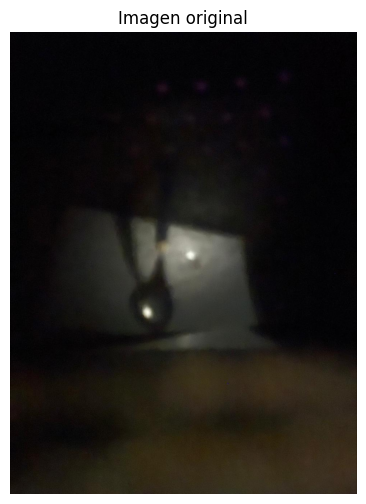

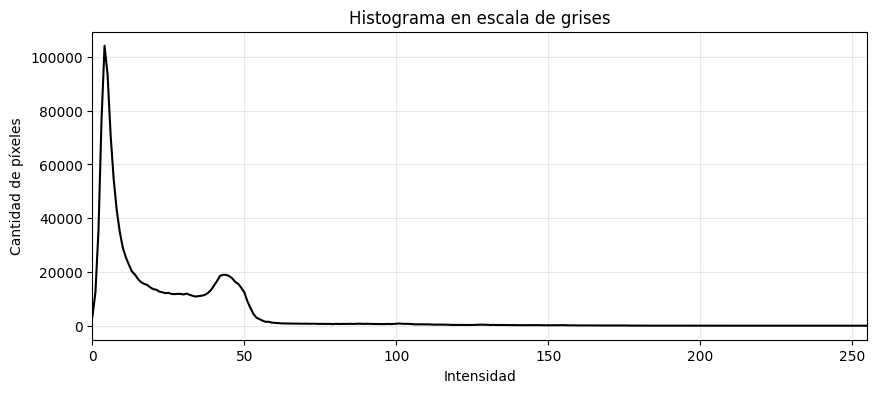

In [11]:
nombre_imagen = "mi_camara_oscura.jpg"

ruta = Path(r"C:\Users\Cristian\Desktop\greco-cristian-pdi-1c-2026\003\003 - LAB\mi_camara_oscura.jpg")

imagen_original = cargar_rgb(ruta)



print(f"Archivo cargado: {ruta}")
print(f"Forma: {imagen_original.shape}")
print(f"Tipo de dato: {imagen_original.dtype}")

mostrar_imagen(imagen_original, "Imagen original")
mostrar_histograma_gris(imagen_original)


In [14]:
def mostrar_imagenes(imagenes, titulos, figsize=(12, 4), cmap=None):
    fig, axes = plt.subplots(1, len(imagenes), figsize=figsize)

    # Si hay una sola imagen, axes no es lista
    if len(imagenes) == 1:
        axes = [axes]

    for ax, img, titulo in zip(axes, imagenes, titulos):
        if img.ndim == 2:
            ax.imshow(img, cmap=cmap or "gray")
        else:
            ax.imshow(img)
        ax.set_title(titulo)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

## Parte 2. Diagnóstico inicial

Escribí qué problema principal ves en la imagen. Algunas posibilidades:

- se ve demasiado oscura,
- tiene poco contraste,
- hay ruido,
- sobra mucho fondo y conviene recortar,
- la zona importante queda poco visible.


In [ ]:
problema_principal = "Se ve demasiado oscura y la zona importante queda poco visible"
hipotesis_mejora = ""

print("Problema principal:", problema_principal)
print("Operación que voy a probar primero:", hipotesis_mejora)


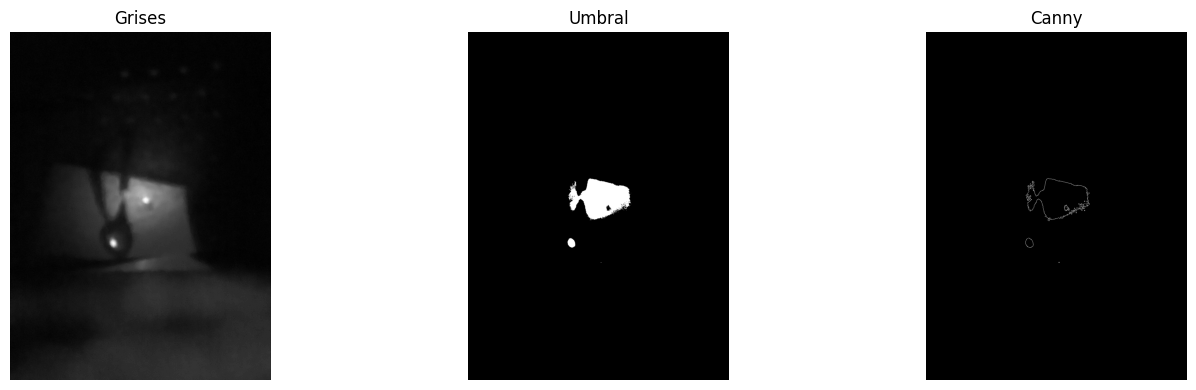

In [19]:
imagen_gris = cv2.cvtColor(imagen_original, cv2.COLOR_RGB2GRAY)
imagen_umbral = segmentar_por_umbral(imagen_gris, 100)
canny = cv2.Canny(imagen_umbral, 50, 150)

mostrar_imagenes(
    [imagen_gris, imagen_umbral, canny],
    ["Grises", "Umbral", "Canny"],
    figsize=(15, 4),
)

## Parte 3. Recorte opcional de la zona útil

Si la imagen tiene mucho fondo innecesario, podés recortar la región más importante antes de mejorarla. Si no necesitás recorte, dejá la imagen completa.


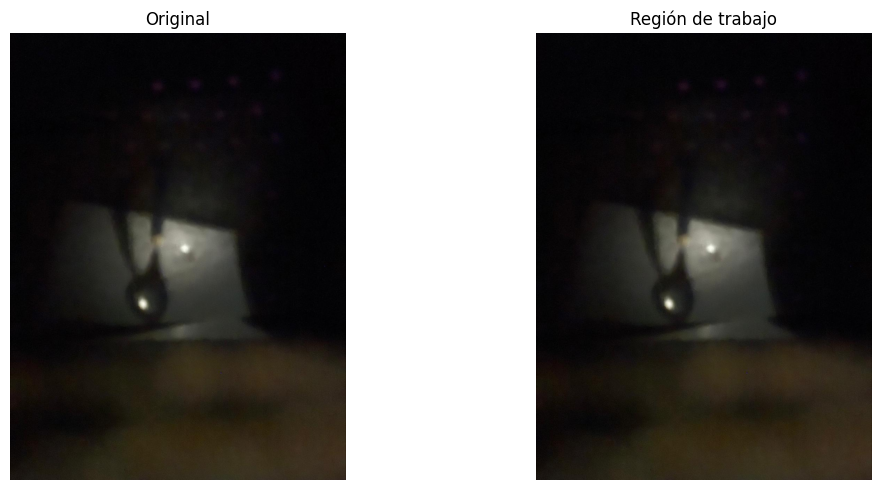

In [20]:
# Si no querés recortar, usá toda la imagen.
y1, y2 = 0, imagen_original.shape[0]
x1, x2 = 0, imagen_original.shape[1]

imagen_recortada = imagen_original[y1:y2, x1:x2]
mostrar_comparacion(imagen_original, imagen_recortada, "Original", "Región de trabajo")


## Parte 4. Probá mejoras de preprocesamiento

Acá tenés tres operaciones posibles. No hace falta usar todas. La idea es que pruebes, compares y decidas cuál te sirve más para preparar la imagen.


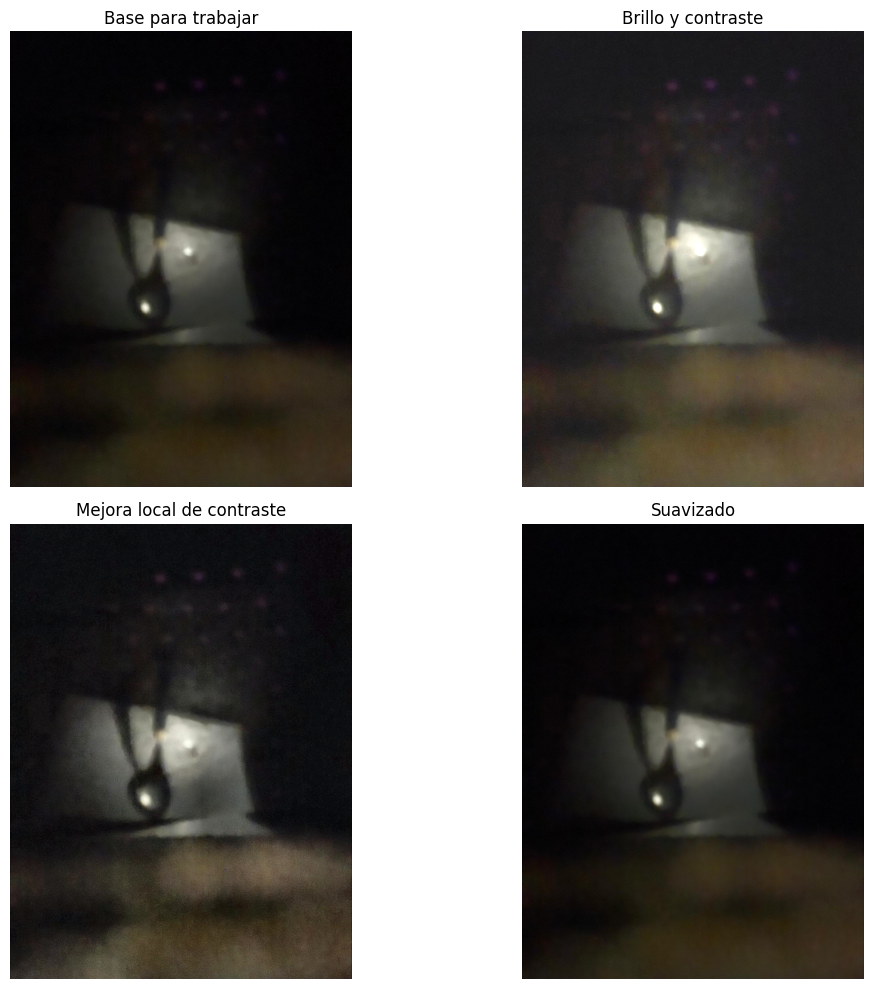

In [21]:
brillo_contraste = ajustar_brillo_contraste(imagen_recortada, alpha=1.4, beta=20)
clahe = mejorar_contraste_clahe(imagen_recortada, clip_limit=2.0, tile=8)
suavizada = suavizar(imagen_recortada, kernel=5)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(imagen_recortada)
axes[0, 0].set_title("Base para trabajar")
axes[0, 0].axis("off")

axes[0, 1].imshow(brillo_contraste)
axes[0, 1].set_title("Brillo y contraste")
axes[0, 1].axis("off")

axes[1, 0].imshow(clahe)
axes[1, 0].set_title("Mejora local de contraste")
axes[1, 0].axis("off")

axes[1, 1].imshow(suavizada)
axes[1, 1].set_title("Suavizado")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()


## Parte 5. Elegí una versión final

Elegí cuál de las variantes te conviene conservar como imagen preprocesada. Si querés, también podés combinar operaciones en dos pasos, por ejemplo: primero mejorar contraste y después suavizar.


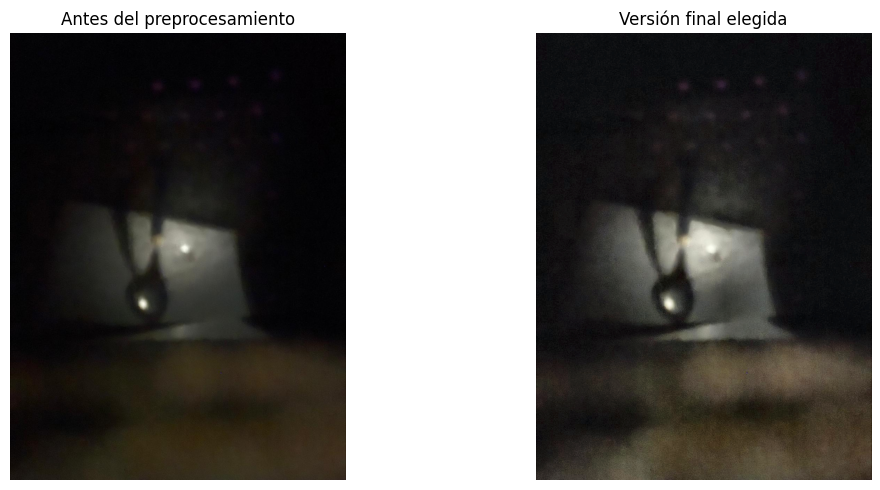

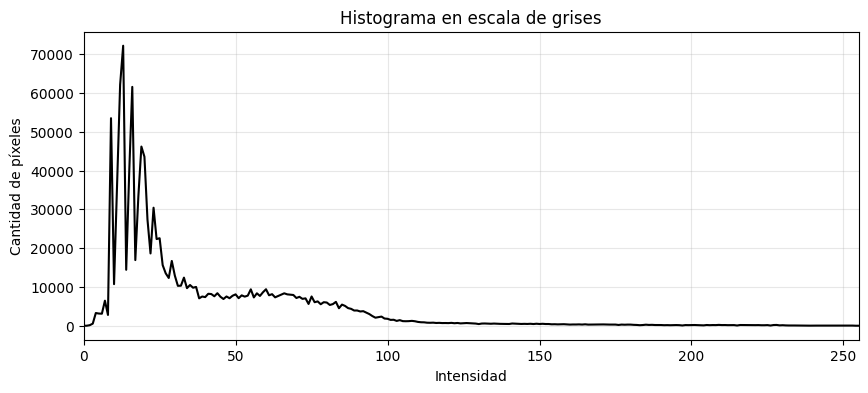

In [22]:
# Elegí una opción o combiná operaciones.
imagen_preprocesada = clahe

# Ejemplo de combinación posible:
# imagen_preprocesada = suavizar(ajustar_brillo_contraste(imagen_recortada, alpha=1.3, beta=15), kernel=5)

mostrar_comparacion(imagen_recortada, imagen_preprocesada, "Antes del preprocesamiento", "Versión final elegida")
mostrar_histograma_gris(imagen_preprocesada)


## Parte 6. Guardá el resultado para la actividad integradora

El objetivo es que el próximo cuaderno pueda tomar esta imagen como punto de partida.


In [ ]:
salida = Path("imagen_preprocesada.png")
cv2.imwrite(str(salida), cv2.cvtColor(imagen_preprocesada, cv2.COLOR_RGB2BGR))
print(f"Imagen guardada en: {salida.resolve()}")


Imagen guardada en: C:\Users\Cristian\Desktop\greco-cristian-pdi-1c-2026\003\003 - LAB\imagen_preprocesada.png


: 

## Cierre escrito

Respondé con tus palabras:

1. ¿Qué problema principal tenía la imagen original?
2. ¿Qué operación u operaciones usaste para mejorarla?
3. ¿Qué cambió entre la imagen original y la preprocesada?
4. ¿Por qué pensás que esta nueva versión puede servir mejor para segmentar?

### Siguiente paso

Usá `imagen_preprocesada.png` en `008 - actividad integradora - segmentacion por color.ipynb` como imagen de entrada principal.
